# Task 3 — NLP Analysis



## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)

## 1. Sanity-check the pipeline on a few sample remarks



In [2]:
from src.task3_nlp.ner import extract_entities
from src.task3_nlp.activities import classify_activity

samples = [
    "Continued POOH with 17 1/2 inch BHA from 1798 m to 1661 m MD pumping at 3500 lpm. Rotated at 40 rpm on 15 MT overpull.",
    "Mud pumps #2 and #3 out of service. Repaired pumps.",
    "Tight hole at 1335 m MD when stabilizer entering shoetrack. Unable to pull without swabbing.",
    "Differential stuck while RIH with 20 inch casing. Mud was replaced to seawater. 300 m3 pumped.",
    "Drilled and oriented 17 1/2 inch hole from 2474 m to 2591 m MD. SPP 274 bar / 140 RPM / torque 32 kNm / ECD 1.45.",
    "Circulated hole clean with 4500 lpm.",
    "Performed leak off test at 1.5 sg.",
]

for s in samples:
    print(f"\nREMARK: {s}")
    print(f"  Activities: {classify_activity(s, max_labels=3)}")
    ents = extract_entities(s)
    for e in ents:
        print(f"  [{e.label:12s}] {e.text!r:30s}  value={e.value!r}  unit={e.unit!r}")


REMARK: Continued POOH with 17 1/2 inch BHA from 1798 m to 1661 m MD pumping at 3500 lpm. Rotated at 40 rpm on 15 MT overpull.
  Activities: ['TRIP_OUT']
  [BIT_SIZE    ] '17 1/2 inch'                   value='17.5'  unit='"'
  [EQUIPMENT   ] 'BHA'                           value='BHA'  unit=None
  [DEPTH       ] '1798 m'                        value='1798'  unit='m'
  [DEPTH       ] '1661 m MD'                     value='1661'  unit='mMD'
  [MEASUREMENT ] '3500 lpm'                      value='3500'  unit='lpm'
  [MEASUREMENT ] '40 rpm'                        value='40'  unit='rpm'
  [MEASUREMENT ] '15 MT'                         value='15'  unit='MT'

REMARK: Mud pumps #2 and #3 out of service. Repaired pumps.
  Activities: ['EQUIPMENT_FAILURE', 'REPAIR']
  [EQUIPMENT   ] 'Mud pumps'                     value='MUD PUMPS'  unit=None

REMARK: Tight hole at 1335 m MD when stabilizer entering shoetrack. Unable to pull without swabbing.
  Activities: ['TIGHT_HOLE']
  [DEPTH       ] '1335

## 2. Run the full pipeline

Reads operations + reports from DuckDB, runs NER + classifier + TF-IDF, runs the bonus analytics, writes all CSVs to `outputs/`.

In [3]:
from src.task3_nlp.run_nlp import run_nlp

summary = run_nlp(top_keywords_n=10, severity_threshold=5)
summary

INFO     ============================================================

INFO     Task 3 — NLP analysis

INFO     ============================================================

INFO     Loaded 11199 operations, 1000 reports.

INFO     Running NER on 11199 operations.

...

INFO     Wrote severity scores →                                                                                   
         C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\outputs\task3_severity_scores.csv

INFO     Wrote activity transitions →                                                                              
         C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\outputs\task3_activity_transitions.csv

INFO     Wrote keywords per well →                                                                                 
         C:\Users\user\Downloads\eilink_ra_ds\eilink_ra_ds\outputs\task3_keywords_per_well.csv

INFO     Summary: {'n_operations': 11199, 'n_reports': 1000, 'n_entities': 31201, 'n_activity_rows': 11199,        
         'n_keyword_rows': 9954, 'n_failure_rows': 30, 'n_severity_rows': 1065, 'n_transitions': 431, 'outputs':   
         {'entities': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_entities.csv',       
         'activities': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_activity_tags.csv', 
         'keywords': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_keywords.csv',        
         'failures':                                                                                               
         'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\frequent_events_per_well.csv',          
         'severity': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_severity_scores.csv', 
         'transitions':                                                                                            
         'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_activity_transitions.csv',        
         'keywords_per_well':                                                                                      
         'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_keywords_per_well.csv'}}

{'n_operations': 11199,
 'n_reports': 1000,
 'n_entities': 31201,
 'n_activity_rows': 11199,
 'n_keyword_rows': 9954,
 'n_failure_rows': 30,
 'n_severity_rows': 1065,
 'n_transitions': 431,
 'outputs': {'entities': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_entities.csv',
  'activities': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_activity_tags.csv',
  'keywords': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_keywords.csv',
  'failures': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\frequent_events_per_well.csv',
  'severity': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_severity_scores.csv',
  'transitions': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_activity_transitions.csv',
  'keywords_per_well': 'C:\\Users\\user\\Downloads\\eilink_ra_ds\\eilink_ra_ds\\outputs\\task3_keywords_per_well.csv'}}

## 3. Inspect: NER results

Distribution of entity labels and the top entity values per label.

In [4]:
from src.common.config import TASK3_ENTITIES_CSV

entities = pd.read_csv(TASK3_ENTITIES_CSV)
print(f"Total entities extracted: {len(entities):,}\n")

label_counts = entities["entity_label"].value_counts()
print("Distribution by label:")
print(label_counts.to_string())

Total entities extracted: 31,201

Distribution by label:
entity_label
EQUIPMENT      9421
MEASUREMENT    9071
DEPTH          7966
BIT_SIZE       4081
TIME            662


In [ ]:
for label in ["EQUIPMENT", "BIT_SIZE", "MEASUREMENT", "DEPTH", "TIME"]:
    sub = entities[entities["entity_label"] == label]
    if sub.empty:
        continue
    if label == "MEASUREMENT":
        print(f"\n--- {label} — frequency per unit ---")
        print(sub["entity_unit"].value_counts().head(10).to_string())
    else:
        print(f"\n--- {label} — top 15 most frequent values ---")
        print(sub["entity_value"].value_counts().head(15).to_string())


--- EQUIPMENT — top 15 most frequent values ---
entity_value
CASING          1095
CEMENT          1038
BOP              891
BHA              879
DP               868
TDS              533
WELLHEAD         431
PRS              302
MWD              298
HWDP             267
LINER            233
CHOKE            212
DRILLING BHA     177
TRIP TANK        139
DRILL PIPE       137

--- BIT_SIZE — top 15 most frequent values ---
entity_value
5.5       651
8.5       369
9.625     269
7         268
26        259
12.25     258
5         241
17.5      238
10.75     229
3.5       202
30        178
20        139
13.375    121
14        111
36         89

--- MEASUREMENT — frequency per unit ---
entity_unit
bar    2679
lpm    1502
MT     1309
kNm     820
rpm     630
sg      431
SG      398
BAR     390
RPM     291
LPM     219

--- DEPTH — top 15 most frequent values ---
entity_value
20      84
10      81
1000    55
30      55
25      53
500     51
140     50
40      46
3395    40
250     37
5       36

## 4. Inspect: activity classification



In [6]:
from src.common.config import TASK3_ACTIVITY_TAGS_CSV

tags = pd.read_csv(TASK3_ACTIVITY_TAGS_CSV)
print(f"Total tagged operations: {len(tags):,}\n")

print("Primary label distribution:")
print(tags["primary_label"].value_counts().to_string())

Total tagged operations: 11,199

Primary label distribution:
primary_label
OTHER                2343
DRILL                1289
TRIP_IN              1196
TRIP_OUT             1054
EQUIPMENT_FAILURE     939
BOP_OPERATION         813
CIRCULATE             635
CASING                560
CEMENT                428
MAKE_UP               333
TOOLBOX_TALK          302
FISHING               232
REPAIR                156
RIG_UP                138
LAY_DOWN              136
FLOW_CHECK            133
WELL_CONTROL           95
TIGHT_HOLE             90
RIG_DOWN               75
WAIT                   74
SURVEY                 70
PRESSURE_TEST          62
STUCK_PIPE             46


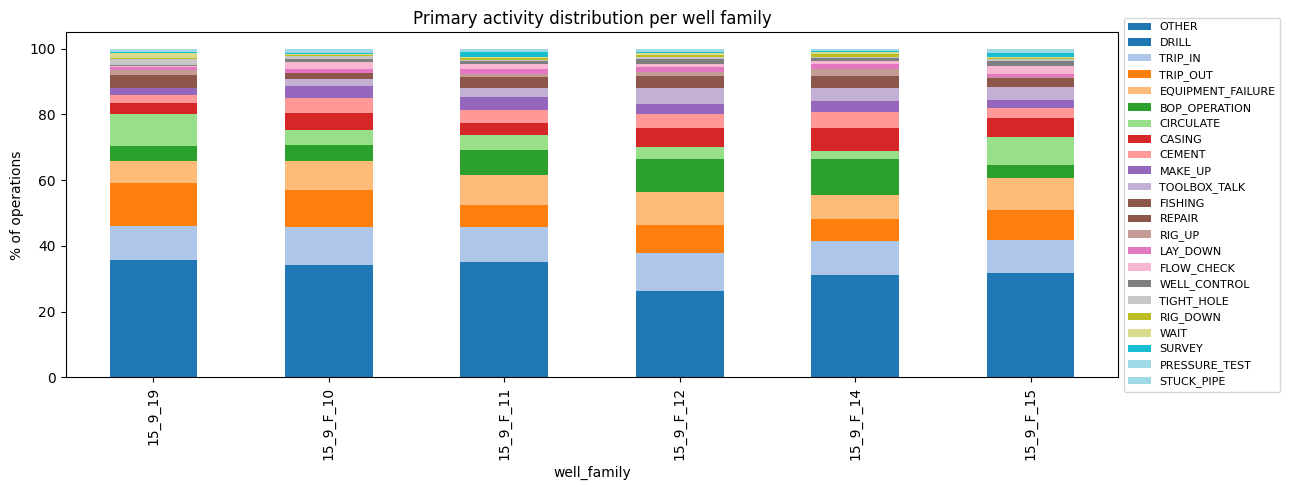

In [ ]:
import matplotlib.pyplot as plt

ct = pd.crosstab(tags["well_family"], tags["primary_label"], normalize="index") * 100
col_order = tags["primary_label"].value_counts().index
ct = ct[col_order]

fig, ax = plt.subplots(figsize=(13, 5))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("% of operations")
ax.set_title("Primary activity distribution per well family")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

## 5. Inspect: TF-IDF keywords per report

In [8]:
from src.common.config import TASK3_KEYWORDS_CSV

keywords = pd.read_csv(TASK3_KEYWORDS_CSV)
print(f"Total keyword rows: {len(keywords):,}")
print(f"Reports covered:    {keywords['pdf_filename'].nunique():,}")
print(f"Distinct keywords:  {keywords['keyword'].nunique():,}")

Total keyword rows: 9,954
Reports covered:    998
Distinct keywords:  4,536


In [ ]:
import random
random_pdfs = random.sample(list(keywords["pdf_filename"].unique()), 3)
for pdf in random_pdfs:
    sub = keywords[keywords["pdf_filename"] == pdf].sort_values("rank")
    print(f"\n=== {pdf} (well={sub.iloc[0]['well_family']}) ===")
    print(sub[["rank", "keyword", "tfidf_score"]].to_string(index=False))


=== 15_9_F_14_2008_06_30.pdf (well=15_9_F_14) ===
 rank         keyword  tfidf_score
    1 wellhead equipm     0.209382
    2 support bracket     0.187784
    3         bracket     0.174750
    4          equipm     0.169154
    5     coflex hose     0.167102
    6 wellhead outlet     0.163970
    7          coflex     0.161396
    8         support     0.161227
    9      equipm ent     0.156705
   10             ent     0.156134

=== 15_9_F_10_2009_06_16.pdf (well=15_9_F_10) ===
 rank          keyword  tfidf_score
    1           camera     0.241240
    2           blower     0.199665
    3      blower hose     0.199665
    4         rigfloor     0.185136
    5 cleared rigfloor     0.174419
    6          general     0.169702
    7  rig maintenance     0.165659
    8  covers moonpool     0.125744
    9        corrotion     0.125744
   10    corrotion cap     0.125744

=== 15_9_19_S_1992_12_17.pdf (well=15_9_19) ===
 rank        keyword  tfidf_score
    1      sidetrack     0.326165


## 6. Bonus: frequent failure patterns per well

Mines the operation remarks for recurring problem-class events per well. Suggests new candidate events for `nds_events.xlsx`.

In [10]:
from src.common.config import FREQUENT_EVENTS_CSV

failures = pd.read_csv(FREQUENT_EVENTS_CSV)
print(f"Failure-pattern rows: {len(failures)}\n")
print(failures[["well_family", "failure_label", "count"]].to_string(index=False))

Failure-pattern rows: 30

well_family     failure_label  count
    15_9_19 EQUIPMENT_FAILURE    204
    15_9_19           FISHING     92
    15_9_19        TIGHT_HOLE     50
    15_9_19        STUCK_PIPE     22
    15_9_19      WELL_CONTROL      9
  15_9_F_10 EQUIPMENT_FAILURE     99
  15_9_F_10        TIGHT_HOLE     12
  15_9_F_10      WELL_CONTROL     10
  15_9_F_10        STUCK_PIPE      9
  15_9_F_10           FISHING      7
  15_9_F_11 EQUIPMENT_FAILURE    194
  15_9_F_11           FISHING     43
  15_9_F_11      WELL_CONTROL     16
  15_9_F_11        TIGHT_HOLE      5
  15_9_F_11        STUCK_PIPE      3
  15_9_F_12 EQUIPMENT_FAILURE    219
  15_9_F_12           FISHING     44
  15_9_F_12      WELL_CONTROL     28
  15_9_F_12        TIGHT_HOLE     12
  15_9_F_12        STUCK_PIPE      3
  15_9_F_14 EQUIPMENT_FAILURE    160
  15_9_F_14           FISHING     72
  15_9_F_14      WELL_CONTROL     16
  15_9_F_14        TIGHT_HOLE      5
  15_9_F_14        STUCK_PIPE      2
  15_9_F_15 

In [ ]:
for well, sub in failures.groupby("well_family"):
    print(f"\n=== {well} ===")
    for _, row in sub.iterrows():
        print(f"  {row['failure_label']:18s} (n={row['count']:>3})")
        for sample in str(row["sample_remarks"]).split(" || ")[:2]:
            print(f"    \"{sample[:130]}\"")


=== 15_9_19 ===
  EQUIPMENT_FAILURE  (n=204)
    "ORIENTED BIT/MOTOR & SLACKED-OFF THROUGH WINDOW.REAMED F/2208-2212M. STARTED DRILLING-SPP INCREASED 35BAR&TDS STALLED Ø16300NM.FRE"
    "FLOW CHECKED, PUMPED SLUG & POOH WITH DRILLING BHA. BIT WAS DAMAGED - 6 OUT OF 9 BLADES ON BIT WERE DAMAGED/BROKEN. NO OTHER DAMAG"
  FISHING            (n= 92)
    "ORIENTED BIT/MOTOR & SLACKED-OFF THROUGH WINDOW.REAMED F/2208-2212M. STARTED DRILLING-SPP INCREASED 35BAR&TDS STALLED Ø16300NM.FRE"
    "MADE UP 7" CSG SPEAR/PACKOFF ASSY AND RIH TO WELLHEAD. abandon -- cut"
  TIGHT_HOLE         (n= 50)
    "CONTINUED TIH; TOOK WEIGHT AT 2207 M. REAMED FROM 2207 - 2245 M; TIGHT HOLE FROM 2207 - 2226 M. HAD TENDENCY OF PACKING-OFF. 16300"
    "WASH AND REAM TIGHT HOLE FROM 3303 - 3820M WITH COREBARREL BHA."
  STUCK_PIPE         (n= 22)
    "MADE UP 7" CSG SPEAR/PACKOFF ASSY AND RIH TO WELLHEAD. abandon -- cut"
    "WORKED AND JARRED ON STUCK PIPE. NO PROGRESS. GOOD CIRCULATION."
  WELL_CONTROL       (n=  9

## 7. Bonus: severity scores — most severe events

Each operation gets a severity score combining its activity label, presence of high-signal text patterns (overpull, lost circulation, twist-off), and the `state == 'fail'` flag.

In [12]:
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
severity = pd.read_csv(OUTPUTS_DIR / "task3_severity_scores.csv")
print(f"Operations with severity ≥ 5: {len(severity):,}\n")

print("Top 15 most severe events across the corpus:")
severity.head(15)[[
    "well_family", "report_date", "severity_score", "severity_contributors",
    "main_activity", "sub_activity", "state", "remark",
]]

Operations with severity ≥ 5: 1,065

Top 15 most severe events across the corpus:


,well_family,report_date,severity_score,severity_contributors,main_activity,sub_activity,state,remark
0,15_9_19,1998-01-29,22,STUCK_PIPE(+8)|FISHING(+6)|text:overpull(+3)|state:fail(+5),plug abando,NaN,fail,"MU 13 3/8"" SPEAR/PACK-OFF ASSEMBLY. ENGAGED 13 3/8"" CASING BELOW WELL- HEAD. UNABLE TO PULL 13 3/8"" CASING FREE WITH 154 MT OVERPULL. ES..."
1,15_9_F_14,2008-06-17,21,WELL_CONTROL(+10)|EQUIPMENT_FAILURE(+4)|FISHING(+6)|REPAIR(+1),interruption,other,ok,Found error in software. Cycled the Iron roughneck and re-booted the software. Equipment Failure Information Start time Depth mMD Depth ...
2,15_9_F_12,2007-09-11,21,WELL_CONTROL(+10)|EQUIPMENT_FAILURE(+4)|FISHING(+6)|REPAIR(+1),interruption,waiting,ok,Watied on weather. Meanwhile worked on PRS. on weather Equipment Failure Information Start time Depth mMD Depth mTVD Sub Equip -- Syst C...
3,15_9_F_12,2007-07-20,20,WELL_CONTROL(+10)|EQUIPMENT_FAILURE(+4)|FISHING(+6),drilling,trip,ok,"Continued to make up 17 1/2"" drilling BHA. Made up NM drillcollar. Equipment Failure Information Start time Depth mMD Depth mTVD Sub Equ..."
4,15_9_19,1997-12-01,18,TIGHT_HOLE(+3)|EQUIPMENT_FAILURE(+4)|FISHING(+6)|state:fail(+5),interrupti,NaN,fail,"FLOWCHECKED - SLIGHT GAIN, RATE OF GAIN FALLING. BEGAN POOH. NORMAL DRAG TO 3087M. TIGHT HOLE 3087M TO 3025M REQUIRED AS MUCH AS 50 TONS..."
5,15_9_F_15,2008-12-09,18,STUCK_PIPE(+8)|EQUIPMENT_FAILURE(+4)|FISHING(+6),drilling,casing,ok,"Broke and laid out 5 1/2"" HWDP and 8 1/4"" DC. Broke and laid down 10 3/4"" Bowen spear and pack off assy. Changed dies in PRS."
6,15_9_F_15,2008-09-21,17,STUCK_PIPE(+8)|FISHING(+6)|text:overpull(+3),interruptio,NaN,ok,Attempted to work string free. Not able to come down - string at TD. Attempted to come up - functioned jar twice. Attempted to work stri...
7,15_9_F_11,2015-10-27,17,WELL_CONTROL(+10)|EQUIPMENT_FAILURE(+4)|REPAIR(+1)|text:swabbing(+2),workover,wire line,ok,Inflow tested / leak tested swab to 20/345 bar for 5/10 min according to program. Leak tested kill wing manifold and hoses to 20/345 bar...
8,15_9_F_10,2009-04-18,17,STUCK_PIPE(+8)|FISHING(+6)|text:overpull(+3),interruptio,NaN,ok,"Attempted to RIH with 20"" casing / 18 3/4"" WH - negative. Worked to free pipe with alternating up/down weights, 50 MT set down / 60 MT o..."
9,15_9_19,1997-11-29,16,FISHING(+6)|text:back-off(+5)|state:fail(+5),interruption --,NaN,fail,FINISHED RIGGING UP ATLAS WIRELINE TO RUN BACKOFF TOOL STRING THROUGH TOP DRIVE. HAD TO RE-RIG SHEAVES BECAUSE OF HIGH DRAG ON THE LO fi...


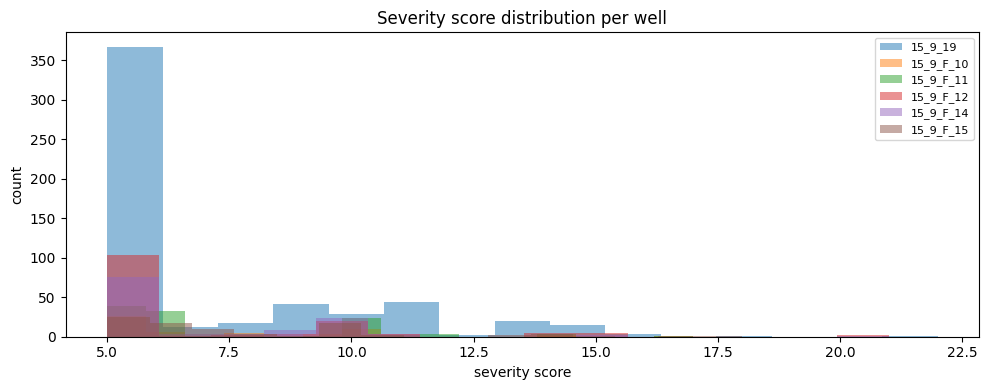

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for well, sub in severity.groupby("well_family"):
    ax.hist(sub["severity_score"], bins=15, alpha=0.5, label=well)
ax.set_xlabel("severity score")
ax.set_ylabel("count")
ax.set_title("Severity score distribution per well")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Bonus: activity transitions

How often does activity Y follow activity X within the same report?

In [14]:
transitions = pd.read_csv(OUTPUTS_DIR / "task3_activity_transitions.csv")
print("Top 20 most common transitions:")
transitions.head(20)

Top 20 most common transitions:


,from_activity,to_activity,count
0,OTHER,OTHER,644
1,DRILL,DRILL,419
2,BOP_OPERATION,BOP_OPERATION,330
3,OTHER,TRIP_IN,273
4,TRIP_IN,OTHER,269
5,OTHER,TRIP_OUT,251
6,TRIP_IN,TRIP_IN,223
7,TRIP_OUT,OTHER,213
8,CASING,CASING,186
9,TRIP_OUT,TRIP_OUT,182


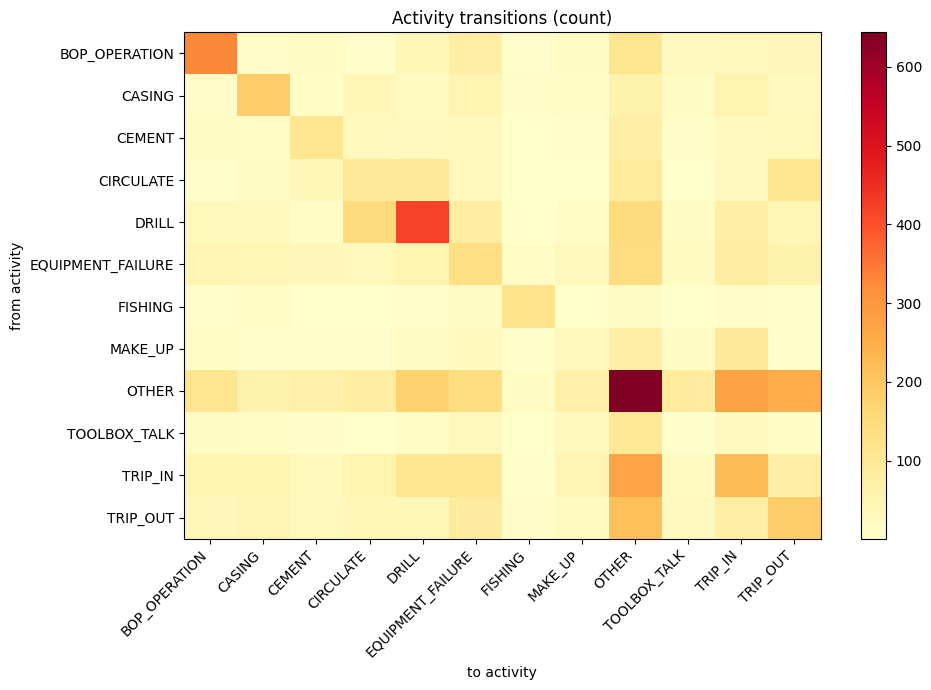

In [ ]:
import numpy as np

TOP_LABELS = transitions.groupby("from_activity")["count"].sum().sort_values(ascending=False).head(12).index
tr_top = transitions[
    transitions["from_activity"].isin(TOP_LABELS)
    & transitions["to_activity"].isin(TOP_LABELS)
]
matrix = tr_top.pivot_table(index="from_activity", columns="to_activity",
                            values="count", fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(matrix.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)
ax.set_xlabel("to activity")
ax.set_ylabel("from activity")
ax.set_title("Activity transitions (count)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 9. Bonus: most distinctive keywords per well

What vocabulary distinguishes well X from the others?

In [16]:
kpw = pd.read_csv(OUTPUTS_DIR / "task3_keywords_per_well.csv")
for well, sub in kpw.groupby("well_family"):
    top = sub.head(10)
    print(f"\n=== {well} (top keywords by # reports they appear in) ===")
    print(top[["keyword", "n_reports"]].to_string(index=False))


=== 15_9_19 (top keywords by # reports they appear in) ===
         keyword  n_reports
       suspended         34
             ofs         32
      ofs strike         32
          strike         32
   suspended ofs         32
 strike continue         30
strike suspended         30
continue waiting         29
     waiting ofs         29
            core         23

=== 15_9_F_10 (top keywords by # reports they appear in) ===
         keyword  n_reports
             ton          9
         ton rop          9
      torque rop          8
         wob ton          8
   according dds          4
       conductor          4
             dds          4
dds instructions          4
           hivis          4
         min wob          4

=== 15_9_F_11 (top keywords by # reports they appear in) ===
       keyword  n_reports
     liter min         16
         liter         15
   average rop         13
   perforation         11
    orientated         10
       tractor          9
      wireline    